# Analisis Pre-Post: impacto de la intervencion

Este notebook muestra el paso a paso para:
- Cargar los Excel de pretest y postest
- Comparar IDs (correo)
- Emparejar participantes
- Calcular metricas globales y por pregunta
- Evaluar significancia estadistica (Wilcoxon pareado)
- Calcular delta y tamano del efecto (Cohen's d)

## 1) Importar librerias

In [ ]:
import warnings
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('Librerias importadas correctamente')

Librerias importadas correctamente


## 2) Configuracion y funciones auxiliares

In [12]:
BASE_DIR = Path('..')
RAW_DIR = BASE_DIR / 'data' / 'raw'
OUTPUTS_DIR = BASE_DIR / 'outputs'

PRETEST_PATH = RAW_DIR / 'Experiencia_en_el_uso_de_Power_App_B-Lab.xlsx'
POSTEST_PATH = RAW_DIR / 'Experiencia_en_el_uso_de_Power_App_B-Lab - postest.xlsx'

LIKERT_MAP = {
    'totalmente en desacuerdo': 1,
    'en desacuerdo': 2,
    'ni de acuerdo ni en desacuerdo': 3,
    'neutral': 3,
    'de acuerdo': 4,
    'totalmente de acuerdo': 5,
}

METADATA_COLUMNS = ['Id', 'Hora de inicio', 'Hora de finalizacion', 'Hora de finalización', 'Correo electrónico', 'Nombre']
OPEN_TEXT_COLUMNS = [
    'Si pudieras cambiar solo una cosa para mejorar la Power App, ¿Cuál sería?',
    'En tu día a día, ¿Qué te impediría hacer uso de la PowerApp?',
]

def normalize_text(value: object) -> str:
    if pd.isna(value):
        return ''
    text = str(value).strip().lower()
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text)
    return text

def map_likert(value: object) -> float:
    return LIKERT_MAP.get(normalize_text(value), float('nan'))

def effect_size_d_paired(pre_vals: np.ndarray, post_vals: np.ndarray) -> float:
    diffs = post_vals - pre_vals
    std = diffs.std(ddof=1)
    if std == 0 or np.isnan(std):
        return np.nan
    return diffs.mean() / std

def classify_d(d: float) -> str:
    if pd.isna(d):
        return 'No calculable'
    a = abs(d)
    if a < 0.2:
        return 'Muy pequeno'
    if a < 0.5:
        return 'Pequeno'
    if a < 0.8:
        return 'Mediano'
    return 'Grande'

print(f'PRETEST_PATH: {PRETEST_PATH}')
print(f'POSTEST_PATH: {POSTEST_PATH}')

PRETEST_PATH: ..\data\raw\Experiencia_en_el_uso_de_Power_App_B-Lab.xlsx
POSTEST_PATH: ..\data\raw\Experiencia_en_el_uso_de_Power_App_B-Lab - postest.xlsx


## 3) Cargar Excel y revisar estructura

In [13]:
pretest_df = pd.read_excel(PRETEST_PATH)
postest_df = pd.read_excel(POSTEST_PATH)

print(f'Pretest: {pretest_df.shape[0]} filas, {pretest_df.shape[1]} columnas')
print(f'Postest: {postest_df.shape[0]} filas, {postest_df.shape[1]} columnas')

display(pretest_df.head(3))
display(postest_df.head(3))

Pretest: 28 filas, 18 columnas
Postest: 17 filas, 18 columnas


,Id,Hora de inicio,Hora de finalización,Correo electrónico,Nombre,Sé cómo navegar la herramienta.Selecciona,"Entiendo el propósito de cada sección de la app (""¿Qué son las Ciencias del Comportamiento?"", ""Diseña tu Intervención Comportamental"", ""Registra el impacto de tu intervención"").Selecciona",Los términos usados en la Power App que son nuevos para mí los entiendo con facilidad.Selecciona,Puedo asociar el contenido teórico de la Power App con los retos que tengo en mi rol .Selecciona,"Las herramientas prácticas que te permiten diligenciar campos e interactuar con la app en la sección de ""Diseña tu Intervención Comportamental"" facilitan diseñar intervenciones..Selecciona",Siento que la app puede ser mi herramienta principal para realizar una intervención comportamental .Selecciona,Usar esta herramienta me motiva a aplicar Ciencias del Comportamiento en mis proyectos..Selecciona,Considero que la herramienta mejora/facilita la aplicación de Ciencias del Comportamiento.Selecciona,La usaría en futuras iniciativas. .Selecciona,Comparto con otras personas conocimientos encontrados en la herramienta .Selecciona,Considero que esta App puede ser útil incluso para colaboradores que no han tenido espacios con B-Lab..Selecciona,"Si pudieras cambiar solo una cosa para mejorar la Power App, ¿Cuál sería?","En tu día a día, ¿Qué te impediría hacer uso de la PowerApp?"
0,2,2026-03-12 16:43:00,2026-03-12 16:44:00,alexamun@bancolombia.com.co,Alexander Muñoz Cardona,En desacuerdo,En desacuerdo,En desacuerdo,En desacuerdo,En desacuerdo,En desacuerdo,En desacuerdo,En desacuerdo,En desacuerdo,En desacuerdo,En desacuerdo,NaN,NaN
1,3,2026-03-12 16:56:00,2026-03-12 16:56:00,luhenao@nequi.com,Luisa Fernanda Henao Medina,Totalmente en desacuerdo,En desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,Totalmente en desacuerdo,NaN,NaN
2,4,2026-03-12 16:55:00,2026-03-12 16:58:00,higomez@bancolombia.com.co,Hilmer Gomez Mejia,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,De acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,De acuerdo,Totalmente de acuerdo,"Veo que la herramienta es muy útil para diseñar intervenciones que promuevan comportamiento. Sin embargo, considero ...",Creo que nada


,Id,Hora de inicio,Hora de finalización,Correo electrónico,Nombre,Sé cómo navegar la herramienta.Selecciona,"Entiendo el propósito de cada sección de la app (""¿Qué son las Ciencias del Comportamiento?"", ""Diseña tu Intervención Comportamental"", ""Registra el impacto de tu intervención"").Selecciona",Los términos usados en la Power App que son nuevos para mí los entiendo con facilidad.Selecciona,Puedo asociar el contenido teórico de la Power App con los retos que tengo en mi rol .Selecciona,"Las herramientas prácticas que te permiten diligenciar campos e interactuar con la app en la sección de ""Diseña tu Intervención Comportamental"" facilitan diseñar intervenciones..Selecciona",Siento que la app puede ser mi herramienta principal para realizar una intervención comportamental .Selecciona,Usar esta herramienta me motiva a aplicar Ciencias del Comportamiento en mis proyectos..Selecciona,Considero que la herramienta mejora/facilita la aplicación de Ciencias del Comportamiento.Selecciona,La usaría en futuras iniciativas. .Selecciona,Comparto con otras personas conocimientos encontrados en la herramienta .Selecciona,Considero que esta App puede ser útil incluso para colaboradores que no han tenido espacios con B-Lab..Selecciona,"Si pudieras cambiar solo una cosa para mejorar la Power App, ¿Cuál sería?","En tu día a día, ¿Qué te impediría hacer uso de la PowerApp?"
0,2,2026-06-04 16:14:00,2026-06-04 16:16:00,higomez@bancolombia.com.co,Hilmer Gomez Mejia,Totalmente de acuerdo,De acuerdo,De acuerdo,Totalmente de acuerdo,De acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,De acuerdo,Totalmente de acuerdo,Ni en acuerdo ni en desacuerdo,Totalmente de acuerdo,Poder consultar información previamente registrada.,NaN
1,3,2026-06-04 16:21:00,2026-06-04 16:23:00,mlmontoy@bancolombia.com.co,Martha Liliana Montoya Diaz,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,nada todo practico,tiempo
2,4,2026-06-04 21:34:00,2026-06-04 21:34:00,luhenao@nequi.com,Luisa Fernanda Henao Medina,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,Totalmente de acuerdo,NaN,NaN


## 4) Comparar IDs (correo) y cobertura

In [14]:
pre_emails = set(pretest_df['Correo electrónico'].dropna().apply(normalize_text))
post_emails = set(postest_df['Correo electrónico'].dropna().apply(normalize_text))
comunes = sorted(pre_emails & post_emails)

print('Cobertura')
print(f'- Personas unicas PRE: {len(pre_emails)}')
print(f'- Personas unicas POST: {len(post_emails)}')
print(f'- Pares comparables: {len(comunes)}')
print(f'- Solo PRE: {len(pre_emails - post_emails)}')
print(f'- Solo POST: {len(post_emails - pre_emails)}')
if len(pre_emails) > 0:
    print(f"- Tasa de retencion: {len(comunes) / len(pre_emails) * 100:.1f}%")

Cobertura
- Personas unicas PRE: 28
- Personas unicas POST: 17
- Pares comparables: 16
- Solo PRE: 12
- Solo POST: 1
- Tasa de retencion: 57.1%


## 5) Emparejar pre/post y construir matriz numerica

In [15]:
def prepare_prepost_data(pre_df: pd.DataFrame, post_df: pd.DataFrame):
    pre_df = pre_df.copy()
    post_df = post_df.copy()

    pre_df['email_norm'] = pre_df['Correo electrónico'].apply(normalize_text)
    post_df['email_norm'] = post_df['Correo electrónico'].apply(normalize_text)

    common_emails = sorted(list(set(pre_df['email_norm']) & set(post_df['email_norm'])))

    pre_paired = pre_df[pre_df['email_norm'].isin(common_emails)].set_index('email_norm').sort_index()
    post_paired = post_df[post_df['email_norm'].isin(common_emails)].set_index('email_norm').sort_index()

    cols_pre = set(pre_paired.columns)
    cols_post = set(post_paired.columns)
    candidate_questions = sorted(list(cols_pre & cols_post))
    likert_questions = [
        c for c in candidate_questions
        if c not in METADATA_COLUMNS + OPEN_TEXT_COLUMNS + ['email_norm']
    ]

    paired_data = pd.DataFrame(index=common_emails)
    for q in likert_questions:
        paired_data[f'{q}_pre'] = pre_paired[q].apply(map_likert)
        paired_data[f'{q}_post'] = post_paired[q].apply(map_likert)

    pre_cols = [c for c in paired_data.columns if c.endswith('_pre')]
    post_cols = [c for c in paired_data.columns if c.endswith('_post')]
    paired_data['indice_global_pre'] = paired_data[pre_cols].mean(axis=1)
    paired_data['indice_global_post'] = paired_data[post_cols].mean(axis=1)

    return paired_data, likert_questions

paired_df, likert_questions = prepare_prepost_data(pretest_df, postest_df)

print(f'Pares construidos: {len(paired_df)}')
print(f'Preguntas Likert detectadas: {len(likert_questions)}')
display(paired_df.head(3))

Pares construidos: 16
Preguntas Likert detectadas: 11


,Comparto con otras personas conocimientos encontrados en la herramienta .Selecciona_pre,Comparto con otras personas conocimientos encontrados en la herramienta .Selecciona_post,Considero que esta App puede ser útil incluso para colaboradores que no han tenido espacios con B-Lab..Selecciona_pre,Considero que esta App puede ser útil incluso para colaboradores que no han tenido espacios con B-Lab..Selecciona_post,Considero que la herramienta mejora/facilita la aplicación de Ciencias del Comportamiento.Selecciona_pre,Considero que la herramienta mejora/facilita la aplicación de Ciencias del Comportamiento.Selecciona_post,"Entiendo el propósito de cada sección de la app (""¿Qué son las Ciencias del Comportamiento?"", ""Diseña tu Intervención Comportamental"", ""Registra el impacto de tu intervención"").Selecciona_pre","Entiendo el propósito de cada sección de la app (""¿Qué son las Ciencias del Comportamiento?"", ""Diseña tu Intervención Comportamental"", ""Registra el impacto de tu intervención"").Selecciona_post",La usaría en futuras iniciativas. .Selecciona_pre,La usaría en futuras iniciativas. .Selecciona_post,"Las herramientas prácticas que te permiten diligenciar campos e interactuar con la app en la sección de ""Diseña tu Intervención Comportamental"" facilitan diseñar intervenciones..Selecciona_pre","Las herramientas prácticas que te permiten diligenciar campos e interactuar con la app en la sección de ""Diseña tu Intervención Comportamental"" facilitan diseñar intervenciones..Selecciona_post",Los términos usados en la Power App que son nuevos para mí los entiendo con facilidad.Selecciona_pre,Los términos usados en la Power App que son nuevos para mí los entiendo con facilidad.Selecciona_post,Puedo asociar el contenido teórico de la Power App con los retos que tengo en mi rol .Selecciona_pre,Puedo asociar el contenido teórico de la Power App con los retos que tengo en mi rol .Selecciona_post,Siento que la app puede ser mi herramienta principal para realizar una intervención comportamental .Selecciona_pre,Siento que la app puede ser mi herramienta principal para realizar una intervención comportamental .Selecciona_post,Sé cómo navegar la herramienta.Selecciona_pre,Sé cómo navegar la herramienta.Selecciona_post,Usar esta herramienta me motiva a aplicar Ciencias del Comportamiento en mis proyectos..Selecciona_pre,Usar esta herramienta me motiva a aplicar Ciencias del Comportamiento en mis proyectos..Selecciona_post,indice_global_pre,indice_global_post
ahruiz@bancolombia.com.co,NaN,NaN,4.0,2,NaN,4.0,4,NaN,NaN,2,NaN,NaN,NaN,NaN,4.0,4,2.0,NaN,NaN,4.0,NaN,NaN,3.5,3.2
akherrer@nequi.com,2.0,5.0,2.0,5,2.0,5.0,2,5.0,2.0,5,2.0,5.0,2.0,5.0,2.0,5,2.0,5.0,2.0,5.0,2.0,5.0,2.0,5.0
alexamun@bancolombia.com.co,2.0,5.0,2.0,5,2.0,5.0,2,5.0,2.0,5,2.0,5.0,2.0,5.0,2.0,5,2.0,5.0,2.0,5.0,2.0,5.0,2.0,5.0


## 6) Calculos generales: delta, Wilcoxon y efecto global

In [16]:
indice_pre = paired_df['indice_global_pre'].to_numpy()
indice_post = paired_df['indice_global_post'].to_numpy()
delta_global = indice_post - indice_pre

valid_global = ~np.isnan(indice_pre) & ~np.isnan(indice_post)
stat_global, p_global = wilcoxon(indice_post[valid_global], indice_pre[valid_global])

delta_promedio_global = np.nanmean(delta_global)
d_global = effect_size_d_paired(indice_pre[valid_global], indice_post[valid_global])

resumen_global = pd.DataFrame({
    'metrica': ['n_pares', 'indice_pre', 'indice_post', 'delta_global', 'p_wilcoxon', 'cohens_d', 'magnitud_d'],
    'valor': [
        int(valid_global.sum()),
        float(np.nanmean(indice_pre)),
        float(np.nanmean(indice_post)),
        float(delta_promedio_global),
        float(p_global),
        float(d_global) if not pd.isna(d_global) else np.nan,
        classify_d(d_global),
    ]
})

display(resumen_global)

,metrica,valor
0,n_pares,16
1,indice_pre,3.483667
2,indice_post,4.631818
3,delta_global,1.148151
4,p_wilcoxon,0.041227
5,cohens_d,0.685068
6,magnitud_d,Mediano


## 7) Analisis por pregunta: delta, Wilcoxon y efecto

In [17]:
rows = []
for q in likert_questions:
    pre_col = f'{q}_pre'
    post_col = f'{q}_post'

    pre_vals = paired_df[pre_col].to_numpy()
    post_vals = paired_df[post_col].to_numpy()
    valid = ~np.isnan(pre_vals) & ~np.isnan(post_vals)

    if valid.sum() < 2:
        continue

    pre_v = pre_vals[valid]
    post_v = post_vals[valid]
    delta = post_v - pre_v

    stat_q, p_q = wilcoxon(post_v, pre_v)
    d_q = effect_size_d_paired(pre_v, post_v)

    rows.append({
        'pregunta': q,
        'n_pares': int(valid.sum()),
        'promedio_pre': float(pre_v.mean()),
        'promedio_post': float(post_v.mean()),
        'delta_promedio': float((post_v - pre_v).mean()),
        'pct_mejoran': float((delta > 0).mean() * 100),
        'pct_igual': float((delta == 0).mean() * 100),
        'pct_empeoran': float((delta < 0).mean() * 100),
        'p_wilcoxon': float(p_q),
        'cohens_d': float(d_q) if not pd.isna(d_q) else np.nan,
        'magnitud_d': classify_d(d_q),
    })

per_question_df = pd.DataFrame(rows).sort_values('delta_promedio', ascending=False)
display(per_question_df.head(11))

,pregunta,n_pares,promedio_pre,promedio_post,delta_promedio,pct_mejoran,pct_igual,pct_empeoran,p_wilcoxon,cohens_d,magnitud_d
0,Comparto con otras personas conocimientos encontrados en la herramienta .Selecciona,11,3.000000,4.818182,1.818182,72.727273,18.181818,9.090909,0.016341,0.991363,Grande
8,Siento que la app puede ser mi herramienta principal para realizar una intervención comportamental .Selecciona,11,3.454545,4.909091,1.454545,63.636364,27.272727,9.090909,0.027590,0.829784,Grande
4,La usaría en futuras iniciativas. .Selecciona,14,3.571429,4.857143,1.285714,42.857143,57.142857,0.000000,0.025597,0.763581,Mediano
10,Usar esta herramienta me motiva a aplicar Ciencias del Comportamiento en mis proyectos..Selecciona,14,3.571429,4.785714,1.214286,50.000000,42.857143,7.142857,0.024001,0.726102,Mediano
5,"Las herramientas prácticas que te permiten diligenciar campos e interactuar con la app en la sección de ""Diseña tu I...",12,3.583333,4.750000,1.166667,50.000000,33.333333,16.666667,0.064640,0.630470,Mediano
2,Considero que la herramienta mejora/facilita la aplicación de Ciencias del Comportamiento.Selecciona,13,3.615385,4.769231,1.153846,46.153846,46.153846,7.692308,0.040320,0.669039,Mediano
1,Considero que esta App puede ser útil incluso para colaboradores que no han tenido espacios con B-Lab..Selecciona,14,3.500000,4.642857,1.142857,42.857143,42.857143,14.285714,0.056854,0.562236,Mediano
3,"Entiendo el propósito de cada sección de la app (""¿Qué son las Ciencias del Comportamiento?"", ""Diseña tu Intervenció...",15,3.600000,4.733333,1.133333,46.666667,46.666667,6.666667,0.022613,0.709390,Mediano
6,Los términos usados en la Power App que son nuevos para mí los entiendo con facilidad.Selecciona,12,3.666667,4.750000,1.083333,41.666667,41.666667,16.666667,0.087504,0.575958,Mediano
9,Sé cómo navegar la herramienta.Selecciona,13,3.692308,4.769231,1.076923,46.153846,38.461538,15.384615,0.064640,0.597959,Mediano


## 8) Conclusión de significancia

In [18]:
es_significativa = (p_global < 0.05) and (delta_promedio_global > 0)

print('Criterio: p < 0.05 y delta_global > 0')
print(f'p_global: {p_global:.6f}')
print(f'delta_global: {delta_promedio_global:.4f}')
print(f"cohen_d_global: {d_global:.4f} ({classify_d(d_global)})")
print('')
if es_significativa:
    print('CONCLUSION: la intervencion fue significativa')
else:
    print('CONCLUSION: la intervencion no alcanza significancia')

Criterio: p < 0.05 y delta_global > 0
p_global: 0.041227
delta_global: 1.1482
cohen_d_global: 0.6851 (Mediano)

CONCLUSION: la intervencion fue significativa


## 9) Visualizaciones principales

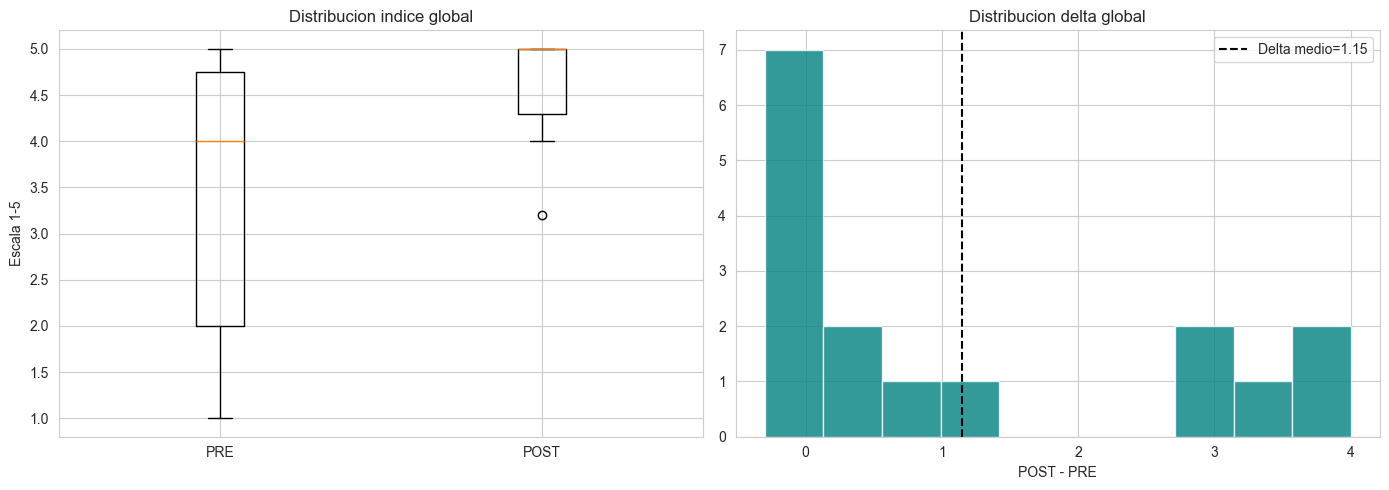

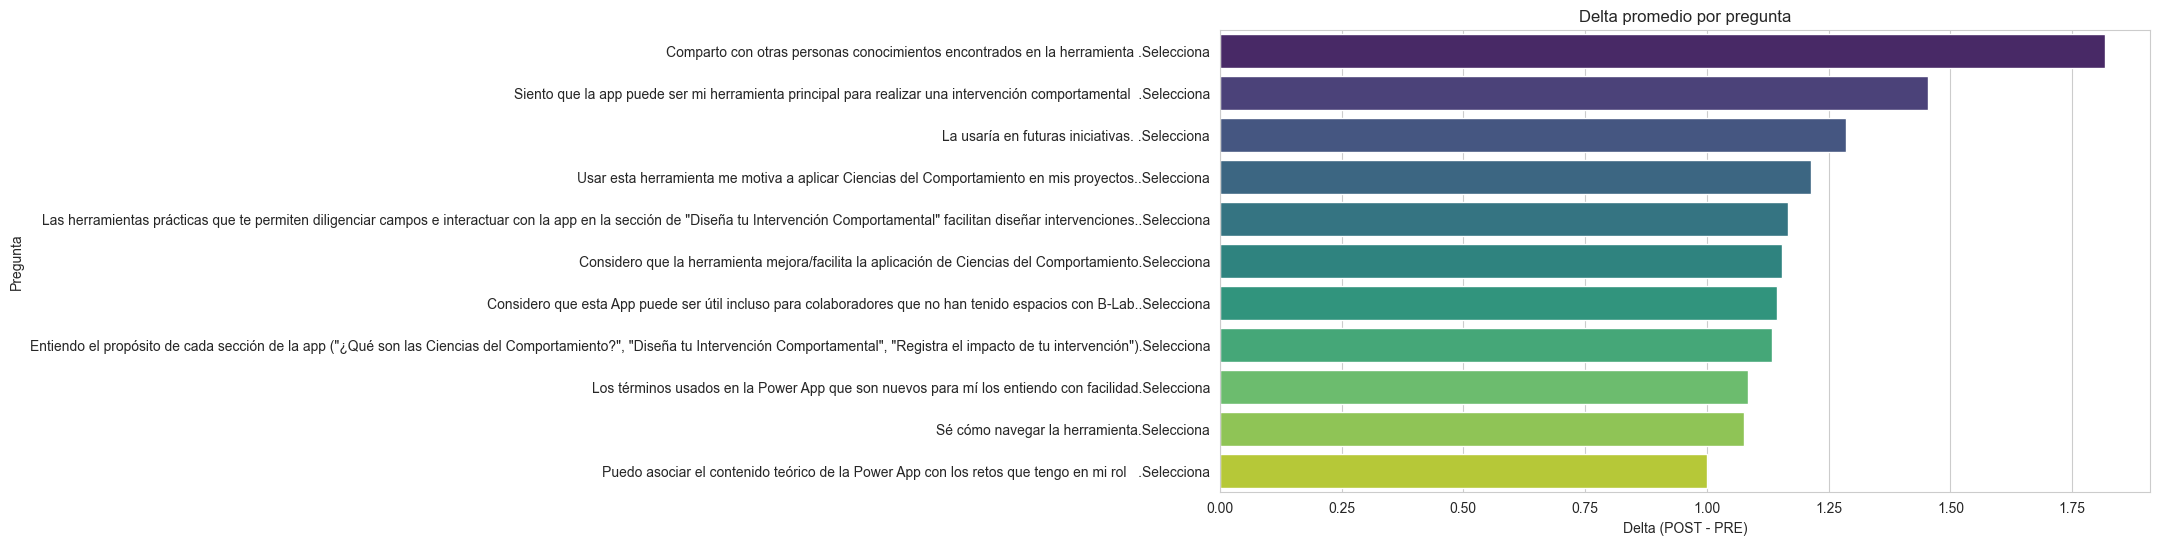

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([indice_pre[valid_global], indice_post[valid_global]], labels=['PRE', 'POST'])
axes[0].set_title('Distribucion indice global')
axes[0].set_ylabel('Escala 1-5')

axes[1].hist(delta_global[~np.isnan(delta_global)], bins=10, color='teal', alpha=0.8)
axes[1].axvline(delta_promedio_global, color='black', linestyle='--', label=f"Delta medio={delta_promedio_global:.2f}")
axes[1].set_title('Distribucion delta global')
axes[1].set_xlabel('POST - PRE')
axes[1].legend()

plt.tight_layout()
plt.show()

plot_df = per_question_df.head(11).copy()
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='delta_promedio', y='pregunta', palette='viridis')
plt.title('Delta promedio por pregunta')
plt.xlabel('Delta (POST - PRE)')
plt.ylabel('Pregunta')
plt.tight_layout()
plt.show()